<a href="https://colab.research.google.com/github/D-Agbikossi/mml-formative3/blob/denaton/Part_1_Probability_Distributions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Distribution Analysis - Temperature vs Humidity

This notebook implements the Bivariate Normal Probability Density Function (PDF)
completely from scratch without using any statistical libraries.
We use real weather data with temperature and humidity features.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import multivariate_normal
import re
from collections import defaultdict
from math import pi, sqrt, exp

In [ ]:
# Step 1: Loading the Dataset
# ============================================================================
# We begin by loading the weather dataset from GitHub. The features we will use are:
#
# Temperature (x) → how hot or cold it is (in °F)
# Humidity (y) → the amount of water vapor in the air (in %)
#
# These two continuous and correlated variables make them ideal for modeling
# using a Bivariate Normal Distribution, which describes relationships between
# two normally distributed variables.

def load_weather_dataset(url="https://raw.githubusercontent.com/D-Agbikossi/mml-formative3/refs/heads/main/GlobalWeatherRepository.csv"):
    try:
        df = pd.read_csv(url)
        print("Dataset loaded successfully.")
        return df
    except Exception as e:
        print("Error loading dataset:", e)
        raise

# Load the data
data = load_weather_dataset()
print("\nFirst few rows of the dataset:")
print(data.head())

df = pd.DataFrame(data)

Dataset loaded successfully.

First few rows of the dataset:
       country     location_name  latitude  longitude        timezone  \
0  Afghanistan             Kabul     34.52      69.18      Asia/Kabul   
1      Albania            Tirana     41.33      19.82   Europe/Tirane   
2      Algeria           Algiers     36.76       3.05  Africa/Algiers   
3      Andorra  Andorra La Vella     42.50       1.52  Europe/Andorra   
4       Angola            Luanda     -8.84      13.23   Africa/Luanda   

   last_updated_epoch      last_updated  temperature_celsius  \
0          1715849100  2024-05-16 13:15                 26.6   
1          1715849100  2024-05-16 10:45                 19.0   
2          1715849100  2024-05-16 09:45                 23.0   
3          1715849100  2024-05-16 10:45                  6.3   
4          1715849100  2024-05-16 09:45                 26.0   

   temperature_fahrenheit condition_text  ...  air_quality_PM2.5  \
0                    79.8  Partly Cloudy  ...  

We will analyze the relationship between two continuous variables from our dataset, for example, temperature_celsius and humidity. The goal is to model their joint distribution using a bivariate normal distribution.

In [ ]:
# Select the two variables for bivariate analysis
feature1 = 'temperature_celsius'
feature2 = 'humidity'

# Drop rows with missing values in these columns
data_bvn = df[[feature1, feature2]].dropna()

print(f"Using {len(data_bvn)} data points for bivariate analysis.")
print(data_bvn.head())

Using 127061 data points for bivariate analysis.
   temperature_celsius  humidity
0                 26.6        24
1                 19.0        94
2                 23.0        29
3                  6.3        61
4                 26.0        89


We need the mean vector μ, the covariance matrix Σ, and the correlation coefficient ρ to define our bivariate normal distribution. We will calculate these from our data.

In [ ]:
# Calculate mean vector
mu_x = np.mean(data_bvn[feature1])
mu_y = np.mean(data_bvn[feature2])
mu = np.array([mu_x, mu_y])

# Calculate covariance matrix
cov_matrix = np.cov(data_bvn[feature1], data_bvn[feature2])
sigma_xx = cov_matrix[0, 0]
sigma_yy = cov_matrix[1, 1]
sigma_xy = cov_matrix[0, 1]

# Calculate correlation coefficient (rho)
rho = sigma_xy / (np.sqrt(sigma_xx) * np.sqrt(sigma_yy))

print("Calculated Parameters:")
print(f"  μ_x (mean {feature1}): {mu_x:.2f}")
print(f"  μ_y (mean {feature2}): {mu_y:.2f}")
print(f"  Σ_xx (variance of {feature1}): {sigma_xx:.2f}")
print(f"  Σ_yy (variance of {feature2}): {sigma_yy:.2f}")
print(f"  Σ_xy (covariance): {sigma_xy:.2f}")
print(f"  ρ (correlation): {rho:.3f}")


Calculated Parameters:
  μ_x (mean temperature_celsius): 21.51
  μ_y (mean humidity): 66.25
  Σ_xx (variance of temperature_celsius): 93.09
  Σ_yy (variance of humidity): 576.98
  Σ_xy (covariance): -79.78
  ρ (correlation): -0.344


We will now implement the Probability Density Function (PDF) for a bivariate normal distribution using its mathematical formula. This is done from scratch without using statistical libraries like scipy.stats.multivariate_normal for the core calculation.

In [ ]:
def bivariate_normal_pdf(x, y, mu_x, mu_y, sigma_x, sigma_y, rho):
    """
    Calculate the Probability Density Function of a bivariate normal distribution.

    Args:
        x, y: Coordinates of the point.
        mu_x, mu_y: Means of the distributions.
        sigma_x, sigma_y: Standard deviations.
        rho: Correlation coefficient.

    Returns:
        The PDF value at (x, y).
    """
    # Calculate the constant factor
    const = 1 / (2 * pi * sigma_x * sigma_y * sqrt(1 - rho**2))

    # Calculate the standardized variables
    z_x = (x - mu_x) / sigma_x
    z_y = (y - mu_y) / sigma_y

    # Calculate the exponent
    exponent = -1 / (2 * (1 - rho**2)) * (z_x**2 - 2 * rho * z_x * z_y + z_y**2)

    pdf_value = const * exp(exponent)
    return pdf_value

# Example: Calculate the PDF value for the first data point
pdf_first_point = bivariate_normal_pdf(data_bvn[feature1].iloc[0],
                                        data_bvn[feature2].iloc[0],
                                        mu_x, mu_y,
                                        np.sqrt(sigma_xx), np.sqrt(sigma_yy),
                                        rho)
print(f"PDF value for the first data point: {pdf_first_point:.6f}")

PDF value for the first data point: 0.000155


To understand the shape of this distribution, we will create a grid of points, calculate the PDF for each point on the grid, and then visualize it using a contour plot and a 3D surface plot.

In [ ]:
# Define the grid boundaries (e.g., using data percentiles to capture most of the data)
x_min, x_max = data_bvn[feature1].quantile(0.01), data_bvn[feature1].quantile(0.99)
y_min, y_max = data_bvn[feature2].quantile(0.01), data_bvn[feature2].quantile(0.99)

# Create a grid
x_grid, y_grid = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]

# Calculate PDF values on the grid
z_grid = np.zeros_like(x_grid)
sigma_x_val = np.sqrt(sigma_xx)
sigma_y_val = np.sqrt(sigma_yy)

for i in range(x_grid.shape[0]):
    for j in range(x_grid.shape[1]):
        z_grid[i, j] = bivariate_normal_pdf(x_grid[i, j], y_grid[i, j],
                                             mu_x, mu_y,
                                             sigma_x_val, sigma_y_val,
                                             rho)

A contour plot shows lines of equal probability density, which will appear as ellipses for a bivariate normal distribution.



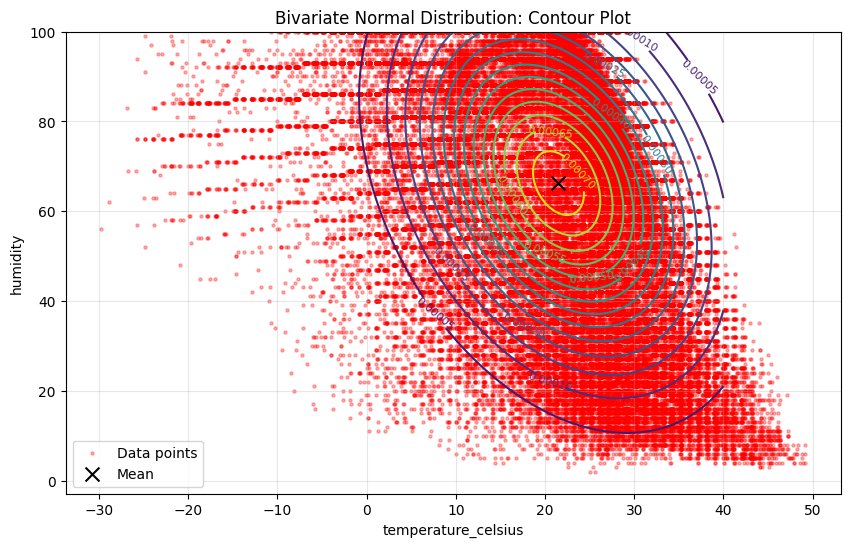

In [ ]:
plt.figure(figsize=(10, 6))
contour = plt.contour(x_grid, y_grid, z_grid, levels=15, cmap='viridis')
plt.clabel(contour, inline=True, fontsize=8)
plt.scatter(data_bvn[feature1], data_bvn[feature2], s=5, alpha=0.3, c='red', label='Data points')
plt.scatter(mu_x, mu_y, c='black', marker='x', s=100, label='Mean')
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.title('Bivariate Normal Distribution: Contour Plot')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

A 3D plot provides a different perspective, showing the 'bell shape' of the probability density surface.

/tmp/ipython-input-375/2494826543.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


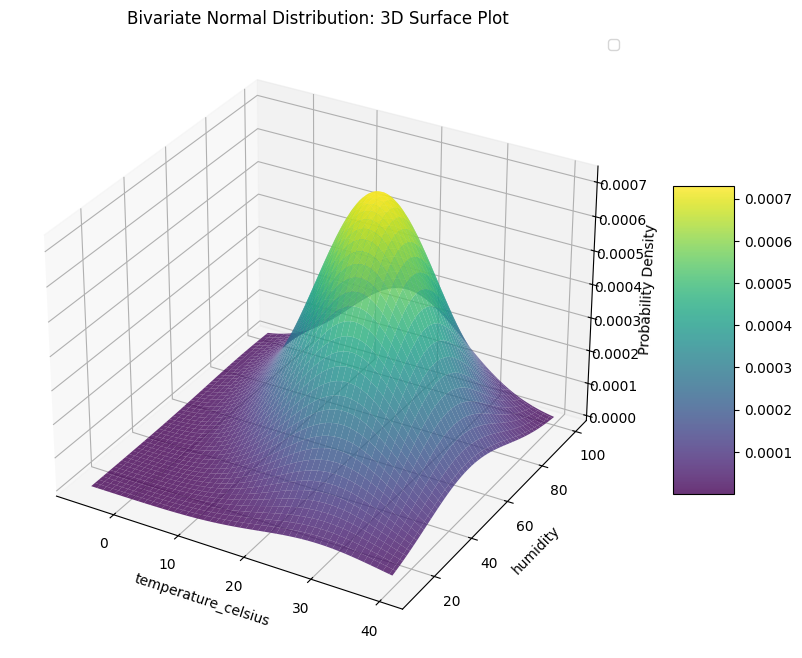

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(x_grid, y_grid, z_grid, cmap='viridis', linewidth=0, antialiased=True, alpha=0.8)

ax.set_xlabel(feature1)
ax.set_ylabel(feature2)
ax.set_zlabel('Probability Density')
ax.set_title('Bivariate Normal Distribution: 3D Surface Plot')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
ax.legend()
plt.show()

# Part 2: Bayesian Probability